Use this script to look at the fraction of tuned cells to different variables in different conditions using venn diagrams
- sig tuned to %escape and shelter distance in explore
- sig tuned to %escape and shelter distance in homing/escape
- triple overlap cells

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

# JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# "JAL3_7sept", "JAL3_4sept", "JAL3_1sept", "JAL3_25aug", "JAL3_22aug",

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

In [2]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

%matplotlib inline

In [3]:
exp = experiments_objects[7]

Experiment(nick_name='JAL006', total_sessions=9, mouse_number_pyrat='BAA-1104292', experiment_file_names=None, root_path=WindowsPath('JAL006'), experiment_name='flip', experiment_idx=4, experiment_date='2024_03_21', experiment_time='11_20_34', experiment_path=WindowsPath('JAL006_shelter_barrier_flip_3_2024_03_21T11_20_34'), shelter_time=[0.25, -1], barrier_time=[59.25, -1], barrier_flip_time=172.5)

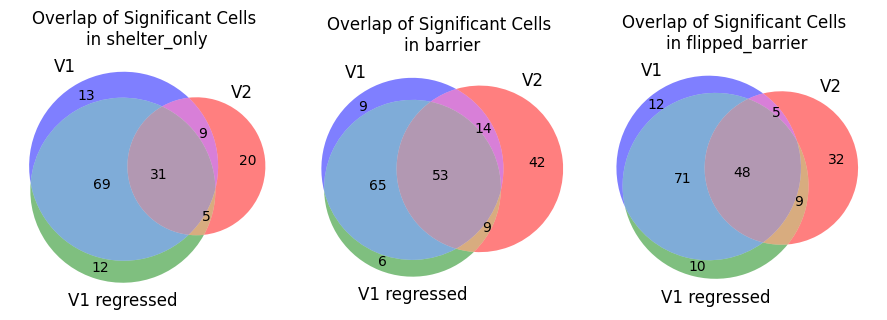

In [13]:
"""How many cells are tuned only to the %escape and not to the distance to shelter in exploration?
Using residuals to identify tuning to %escape surviving from distance to shelter subtraction"""

nickname = exp.nick_name + '_' + exp.experiment_date
c_names = ['shelter_only', 'barrier', 'flipped_barrier']

# 1. load in explore tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
saving_file = dump_path + exp_nickname + '_Tuning.npz'
data = np.load(saving_file)

# pull out the params
data_files = data.files
exp_params_real = data['params_real']
exp_params_shifts = data['params_shifts']

# 2. load in homing/escape tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
data = np.load(saving_file)

data_files = data.files
params_real = data['params_real']
params_shifts = data['params_shifts']

# load in residuals data
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
saving_file = dump_path + exp_nickname + '_ResidualsTuning.npz'
data = np.load(saving_file)
data_files = data.files
params_real_exp = data['params_real_exp']
params_shifts_exp_res = data['params_shifts_exp_res']

# identify cells that are sig tuned to %escape in homing/escape
sig_escape = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)

# identify cells that are sig tuned to distance to shelter in exploration
exp_sig_dist = exp_params_real[:,:,0] > np.nanpercentile(exp_params_shifts[:,:,:,0], 95, axis = 0)

# ifnd cells whose residual tuning to %escape - distance to shelter in exploration is significant
sig_res = params_real_exp[:,:,0] > np.nanpercentile(params_shifts_exp_res[:,:,:,0], 95, axis = 0)

"""Venn diagram"""

fig, axs = plt.subplots(1,3,figsize=(9, 3))
for c in range(3):
    # Compute Set Sizes
    A = np.sum((sig_escape[:, c] == True) & (exp_sig_dist[:, c] == False) & (sig_res[:, c] == False))  # V1 only
    B = np.sum((sig_escape[:, c] == False) & (exp_sig_dist[:, c] == True) & (sig_res[:, c] == False))  # V2 only
    C = np.sum((sig_escape[:, c] == False) & (exp_sig_dist[:, c] == False) & (sig_res[:, c] == True))  # V1 regressed
    AB = np.sum((sig_escape[:, c] == True) & (exp_sig_dist[:, c] == True) & (sig_res[:, c] == False))  # Both V1 and V2
    AC = np.sum((sig_escape[:, c] == True) & (exp_sig_dist[:, c] == False) & (sig_res[:, c] == True))  # Both V1 and V1 regressed
    BC = np.sum((sig_escape[:, c] == False) & (exp_sig_dist[:, c] == True) & (sig_res[:, c] == True))  # Both V2 and V1 regressed
    ABC = np.sum((sig_escape[:, c] == True) & (exp_sig_dist[:, c] == True) & (sig_res[:, c] == True))  # All three

    # Create Venn Diagram
    venn3(subsets=(A, B, AB, C, AC, BC, ABC), 
        set_labels=('V1', 'V2', 'V1 regressed'), 
        set_colors=('blue', 'red', 'green'),
        alpha=0.5,
        ax=axs[c])
    axs[c].set_title('Overlap of Significant Cells \nin ' + c_names[c])
plt.tight_layout()

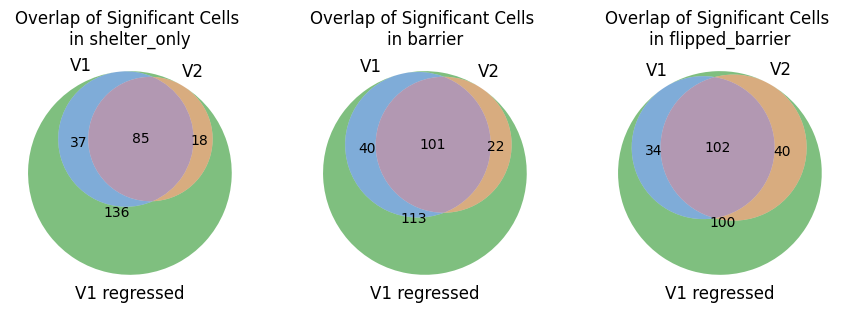

In [18]:
"""How many cells are tuned to the %escape and to the distance to shelter in homing/escape?"""

nickname = exp.nick_name + '_' + exp.experiment_date
c_names = ['shelter_only', 'barrier', 'flipped_barrier']

# 1. load in explore tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
data = np.load(saving_file)

# pull out the params
data_files = data.files
dist_params_real = data['params_real']
dist_params_shifts = data['params_shifts']

# 2. load in homing/escape tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
data = np.load(saving_file)

data_files = data.files
params_real = data['params_real']
params_shifts = data['params_shifts']

# TODO: load in results from TunED


# identify cells that are sig tuned to %escape in homing/escape
sig_escape = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)

# identify cells that are sig tuned to distance to shelter in exploration
sig_dist = dist_params_real[:,:,0] > np.nanpercentile(dist_params_shifts[:,:,:,0], 95, axis = 0)

# ifnd cells whose residual tuning to %escape - distance to shelter in exploration is significant
# sig_res = params_real_exp[:,:,0] > np.nanpercentile(params_shifts_exp_res[:,:,:,0], 95, axis = 0)
tuned_sig = np.full_like(sig_dist, True)

"""Venn diagram"""

fig, axs = plt.subplots(1,3,figsize=(9, 3))
for c in range(3):
    # Compute Set Sizes
    A = np.sum((sig_escape[:, c] == True) & (sig_dist[:, c] == False) & (tuned_sig[:, c] == False))  # V1 only
    B = np.sum((sig_escape[:, c] == False) & (sig_dist[:, c] == True) & (tuned_sig[:, c] == False))  # V2 only
    C = np.sum((sig_escape[:, c] == False) & (sig_dist[:, c] == False) & (tuned_sig[:, c] == True))  # V1 regressed
    AB = np.sum((sig_escape[:, c] == True) & (sig_dist[:, c] == True) & (tuned_sig[:, c] == False))  # Both V1 and V2
    AC = np.sum((sig_escape[:, c] == True) & (sig_dist[:, c] == False) & (tuned_sig[:, c] == True))  # Both V1 and V1 regressed
    BC = np.sum((sig_escape[:, c] == False) & (sig_dist[:, c] == True) & (tuned_sig[:, c] == True))  # Both V2 and V1 regressed
    ABC = np.sum((sig_escape[:, c] == True) & (sig_dist[:, c] == True) & (tuned_sig[:, c] == True))  # All three

    # Create Venn Diagram
    venn3(subsets=(A, B, AB, C, AC, BC, ABC), 
        set_labels=('V1', 'V2', 'TunED V1'), 
        set_colors=('blue', 'red', 'green'),
        alpha=0.5,
        ax=axs[c])
    axs[c].set_title('Overlap of Significant Cells \nin ' + c_names[c])
plt.tight_layout()